# EfficientNetB0 — Experiment 3: Fine-Tuning
Loads best Exp2 model, unfreezes last 30 backbone layers, retrains with very small LR.

In [1]:
import os, re, json
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight

TRAIN_DIR = "/kaggle/input/datasets/usmanafzaal/strawberry-disease-detection-dataset/train"
VAL_DIR   = "/kaggle/input/datasets/usmanafzaal/strawberry-disease-detection-dataset/val"
TEST_DIR  = "/kaggle/input/datasets/usmanafzaal/strawberry-disease-detection-dataset/test"

CLASS_NAMES = [
    'Angular Leafspot',
    'Anthracnose Fruit Rot',
    'Blossom Blight',
    'Gray Mold',
    'Leaf Spot',
    'Powdery Mildew Fruit',
    'Powdery Mildew Leaf'
]

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS_FT  = 15       # Fine-tuning epochs
LR_FT      = 1e-5     # Must be much smaller than Exp1/2
UNFREEZE_N = 30       # Unfreeze last 30 backbone layers
SEED       = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
print('Setup done.')

2026-03-11 01:07:26.869697: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773191247.271809      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773191247.384483      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773191248.295128      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773191248.295177      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773191248.295180      24 computation_placer.cc:177] computation placer alr

Setup done.


In [2]:
# ── Load Exp2 Model ─────────────────────────────────────
# Make sure exp2_efficientnetb0.keras is added as a Kaggle dataset input
model = tf.keras.models.load_model(
    '/kaggle/input/datasets/elaffa/exp2out/exp2_efficientnetb0.keras')
print('Exp2 model loaded.')
model.summary()

I0000 00:00:1773191286.814232      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773191286.817165      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Exp2 model loaded.


Model: "EfficientNetB0_Exp2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,086,714 (15.59 MB)

 Trainable params: 11,527 (45.03 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

 Optimizer params: 23,056 (90.07 KB)

In [3]:
# ── Load Labels from JSON ───────────────────────────────
def load_split(folder):
    data = []
    for f in os.listdir(folder):
        if not f.lower().endswith('.jpg'):
            continue
        img_path  = os.path.join(folder, f)
        json_path = img_path.replace('.jpg', '.json')
        label = None
        if os.path.exists(json_path):
            try:
                with open(json_path) as jf:
                    ann = json.load(jf)
                shapes = ann.get('shapes', [])
                if shapes:
                    label = shapes[0].get('label', None)
            except:
                pass
        if not label:
            name = os.path.splitext(f)[0]
            label = re.sub(r'\d+$', '', name).strip()
        data.append([img_path, label])
    return pd.DataFrame(data, columns=['path', 'label'])

train_df = load_split(TRAIN_DIR)
val_df   = load_split(VAL_DIR)
test_df  = load_split(TEST_DIR)

label2idx   = {name: i for i, name in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)

for df in (train_df, val_df, test_df):
    df['label_idx'] = df['label'].map(label2idx)

weights = compute_class_weight('balanced',
                                classes=np.arange(NUM_CLASSES),
                                y=train_df['label_idx'].values)
class_weight_dict = dict(enumerate(weights))
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

Train: 1450 | Val: 307 | Test: 743


In [4]:
# ── tf.data Pipeline ─────
preprocess = tf.keras.applications.efficientnet.preprocess_input

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = preprocess(img)
    return img, label

def make_dataset(df, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (df['path'].values, df['label_idx'].values))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, shuffle=True)
val_ds   = make_dataset(val_df)
test_ds  = make_dataset(test_df)
print('Datasets ready.')

Datasets ready.


In [5]:
# ── Unfreeze Last N Backbone Layers ─────
backbone = None
for layer in model.layers:
    if 'efficientnetb0' in layer.name.lower():
        backbone = layer
        break

print(backbone.name)

backbone.trainable = True
for layer in backbone.layers[:-UNFREEZE_N]:
    layer.trainable = False

trainable = sum(l.trainable for l in backbone.layers)
print(f'Trainable backbone layers: {trainable} / {len(backbone.layers)}')


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_FT),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

efficientnetb0
Trainable backbone layers: 30 / 238


In [6]:
# ── Fine-Tune ───────────────────────────────────────────
callbacks_ft = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5,
        restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=2, min_lr=1e-7, verbose=1),
]

history3 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FT,
    callbacks=callbacks_ft,
    class_weight=class_weight_dict
)

Epoch 1/15


E0000 00:00:1773191325.695620      24 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_Exp2_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1773191329.286020      68 cuda_dnn.cc:529] Loaded cuDNN version 91002


46/46 ━━━━━━━━━━━━━━━━━━━━ 28s 223ms/step - accuracy: 0.8570 - loss: 0.4460 - val_accuracy: 0.9511 - val_loss: 0.1266 - learning_rate: 1.0000e-05
Epoch 2/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - accuracy: 0.8862 - loss: 0.3595 - val_accuracy: 0.9544 - val_loss: 0.1499 - learning_rate: 1.0000e-05
Epoch 3/15
45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.8911 - loss: 0.3509
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - accuracy: 0.8910 - loss: 0.3502 - val_accuracy: 0.9511 - val_loss: 0.1697 - learning_rate: 1.0000e-05
Epoch 4/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - accuracy: 0.9011 - loss: 0.3386 - val_accuracy: 0.9446 - val_loss: 0.1857 - learning_rate: 5.0000e-06
Epoch 5/15
45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.8893 - loss: 0.3667
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - accuracy: 0.8898 - loss: 0.3651 

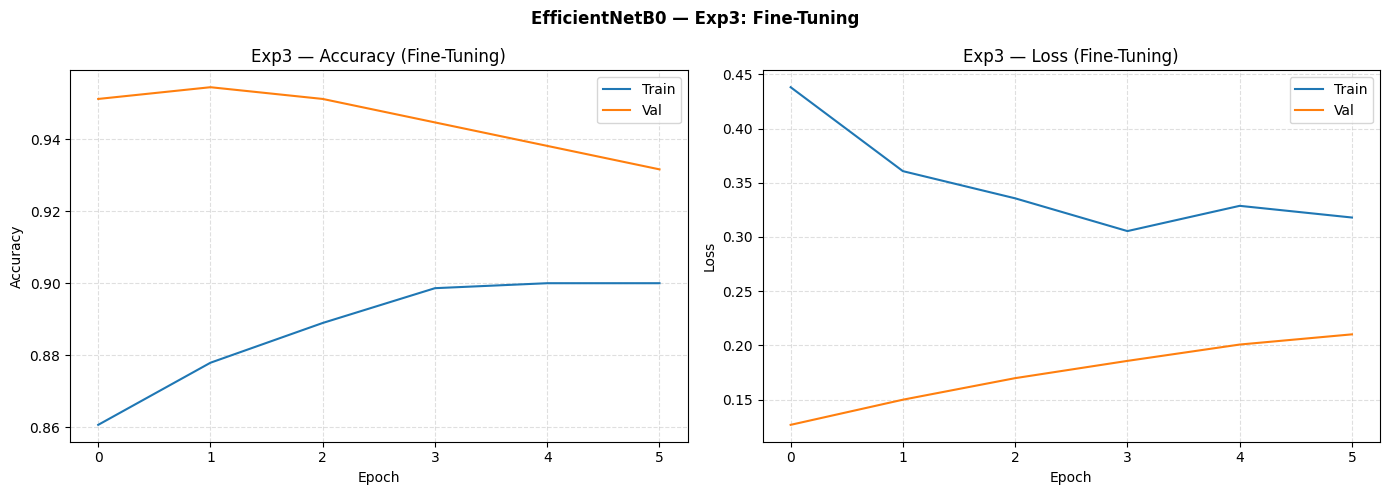

In [7]:
# ── Training Curves ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history3.history['accuracy'],     label='Train')
axes[0].plot(history3.history['val_accuracy'], label='Val')
axes[0].set_title('Exp3 — Accuracy (Fine-Tuning)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(linestyle='--', alpha=0.4)

axes[1].plot(history3.history['loss'],     label='Train')
axes[1].plot(history3.history['val_loss'], label='Val')
axes[1].set_title('Exp3 — Loss (Fine-Tuning)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(linestyle='--', alpha=0.4)

plt.suptitle('EfficientNetB0 — Exp3: Fine-Tuning', fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/exp3_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ── Evaluate on Test Set ────────────────────────────────
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f'[Exp3] Test Loss    : {test_loss:.4f}')
print(f'[Exp3] Test Accuracy: {test_acc:.4f}')

y_true = np.concatenate([y for _, y in test_ds], axis=0)
y_prob = model.predict(test_ds)
y_pred = np.argmax(y_prob, axis=1)

print('\n[Exp3] Classification Report:')
print(classification_report(y_true, y_pred,
      target_names=CLASS_NAMES, digits=4, zero_division=0))

[Exp3] Test Loss    : 0.4241
[Exp3] Test Accuracy: 0.8668
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 146ms/step

[Exp3] Classification Report:
                       precision    recall  f1-score   support

     Angular Leafspot     0.7989    0.9728    0.8773       147
Anthracnose Fruit Rot     0.5833    0.8235    0.6829        34
       Blossom Blight     1.0000    1.0000    1.0000        62
            Gray Mold     0.8636    0.9172    0.8896       145
            Leaf Spot     0.9457    0.7578    0.8414       161
 Powdery Mildew Fruit     0.6216    0.5349    0.5750        43
  Powdery Mildew Leaf     0.9925    0.8808    0.9333       151

             accuracy                         0.8668       743
            macro avg     0.8294    0.8410    0.8285       743
         weighted avg     0.8794    0.8668    0.8672       743



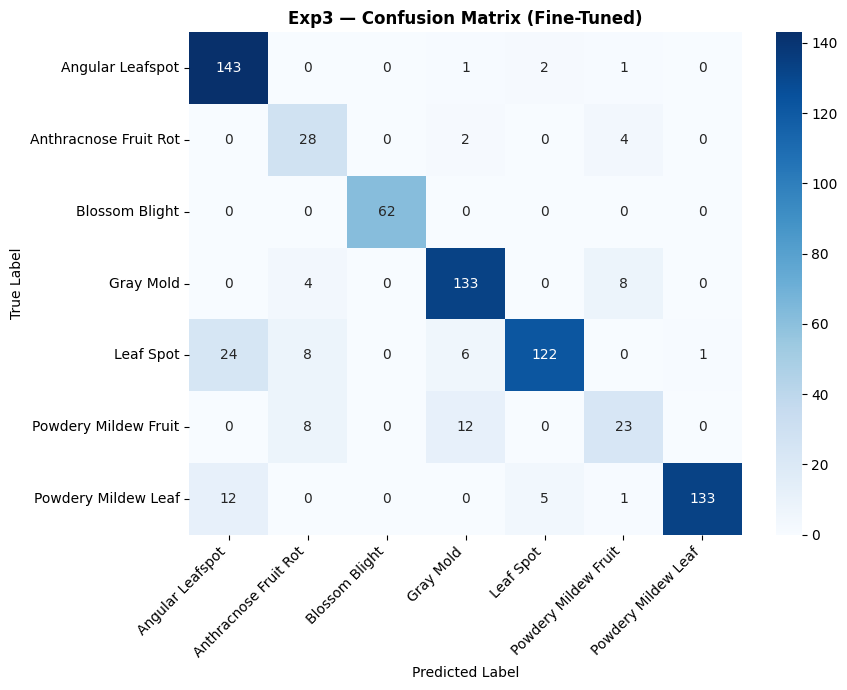

In [9]:
# ── Confusion Matrix ────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Exp3 — Confusion Matrix (Fine-Tuned)', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/kaggle/working/exp3_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ── Save Model + Results CSV ────────────────────────────
model.save('/kaggle/working/exp3_efficientnetb0_finetuned.keras')

exp3_results = {
    'experiment' : 'Exp3 - Fine-Tuned',
    'model'      : 'EfficientNetB0',
    'test_acc'   : round(float(test_acc), 4),
    'test_loss'  : round(float(test_loss), 4),
    'f1_weighted': round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
    'precision'  : round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 4),
    'recall'     : round(recall_score(y_true, y_pred, average='weighted', zero_division=0), 4),
}
pd.DataFrame([exp3_results]).to_csv('/kaggle/working/exp3_results.csv', index=False)
print('Model and results saved!')
print(exp3_results)

Model and results saved!
{'experiment': 'Exp3 - Fine-Tuned', 'model': 'EfficientNetB0', 'test_acc': 0.8668, 'test_loss': 0.4241, 'f1_weighted': 0.8672, 'precision': 0.8794, 'recall': 0.8668}
